# Airbnb Seattle — Exploratory Data Analysis

Regression task: predict nightly listing price from host, property, and location features.

**Dataset:** `data/features.csv` — cleaned and feature-engineered Seattle listings.

---
**Sections**
1. Overview
2. Target Analysis
3. Missing Values
4. Feature Distributions
5. Correlation Matrix
6. Features vs Target
7. Key Findings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
DATA_DIR = Path('../data')

df = pd.read_csv(DATA_DIR / 'features.csv')
print('Loaded features.csv')

Loaded features.csv


---
## 1. Overview

In [2]:
print(f'Shape : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'\nDtype summary:')
print(df.dtypes.value_counts().to_string())
print(f'\nNumeric columns ({df.select_dtypes(include="number").shape[1]}):')
print(df.select_dtypes(include='number').columns.tolist())
print(f'\nCategorical columns ({df.select_dtypes(include="object").shape[1]}):')
print(df.select_dtypes(include='object').columns.tolist())

Shape : 5,927 rows  x  55 columns

Dtype summary:
object     20
float64    19
int64      16

Numeric columns (35):
['host_id', 'host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'availability_30', 'availability_60', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'reviews_per_month', 'amenities_count', 'host_response_rate_num', 'host_acceptance_rate_num', 'days_since_last_review', 'host_quality_score', 'distance_to_downtown', 'neighbourhood_avg_price', 'neighbourhood_group_avg_price']

Categorical columns (20):
['host_name', 'host_since', 'host_location', 'host_resp

In [3]:
df.head(5)

,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,...,reviews_per_month,amenities_count,host_response_rate_num,host_acceptance_rate_num,days_since_last_review,host_quality_score,neighbourhood_group,distance_to_downtown,neighbourhood_avg_price,neighbourhood_group_avg_price
0,14942,Joyce,2009-04-26,"Seattle, WA",within a few hours,100%,82%,t,Wallingford,5.0,...,0.82,29,100.0,82.0,383.0,4.712857,Other neighborhoods,5.373225,217.609756,187.470925
1,30559,Angielena,2009-08-09,"Seattle, WA",within an hour,100%,97%,t,Georgetown,10.0,...,1.19,55,100.0,97.0,25.0,4.782857,Other neighborhoods,6.303002,128.407407,187.470925
2,14942,Joyce,2009-04-26,"Seattle, WA",within a few hours,100%,82%,t,Wallingford,5.0,...,0.51,41,100.0,82.0,1648.0,4.760000,Other neighborhoods,5.335704,217.609756,187.470925
3,102684,Amanda,2010-04-02,"Seattle, WA",within an hour,100%,100%,t,Ballard,1.0,...,6.06,40,100.0,100.0,9.0,4.931429,Ballard,8.677280,152.228571,177.293801
4,114228,Clarice Elaine,2010-04-26,"Seattle, WA",within a few hours,100%,0%,f,Eastlake,1.0,...,0.35,37,100.0,0.0,2028.0,0.000000,Cascade,3.700227,230.423358,236.934694


In [4]:
df.describe(include='number').T.style.format('{:.2f}').background_gradient(cmap='Blues', axis=0)

,count,mean,std,min,25%,50%,75%,max
host_id,5927.00,175962568.38,195160844.76,2536.00,19348878.00,80333752.00,340706410.00,718660999.00
host_listings_count,5927.00,44.48,192.57,1.00,1.00,3.00,17.00,2989.00
host_total_listings_count,5927.00,89.59,502.28,1.00,2.00,4.00,24.00,8403.00
latitude,5927.00,47.63,0.05,47.50,47.60,47.63,47.66,47.73
longitude,5927.00,-122.33,0.03,-122.42,-122.36,-122.33,-122.31,-122.24
accommodates,5927.00,4.14,2.66,1.00,2.00,4.00,6.00,16.00
bedrooms,5916.00,1.69,1.21,0.00,1.00,1.00,2.00,13.00
beds,5927.00,2.22,1.54,0.00,1.00,2.00,3.00,15.00
price,5927.00,590.96,4237.86,15.00,103.00,145.00,212.00,50039.00
minimum_nights,5927.00,9.55,18.00,1.00,1.00,2.00,7.00,365.00


---
## 2. Target Analysis — Price Distribution

In [5]:
price = df['price']
log_price = np.log(price)

stats = pd.DataFrame({
    'Price ($)':     [price.mean(), price.median(), price.std(),
                      price.min(), price.quantile(0.25), price.quantile(0.75),
                      price.max(), price.skew()],
    'Log Price':     [log_price.mean(), log_price.median(), log_price.std(),
                      log_price.min(), log_price.quantile(0.25), log_price.quantile(0.75),
                      log_price.max(), log_price.skew()],
}, index=['Mean', 'Median', 'Std', 'Min', 'P25', 'P75', 'Max', 'Skew'])
print(stats.round(2).to_string())

        Price ($)  Log Price
Mean       590.96       5.05
Median     145.00       4.98
Std       4237.86       0.81
Min         15.00       2.71
P25        103.00       4.63
P75        212.00       5.36
Max      50039.00      10.82
Skew        10.39       3.20


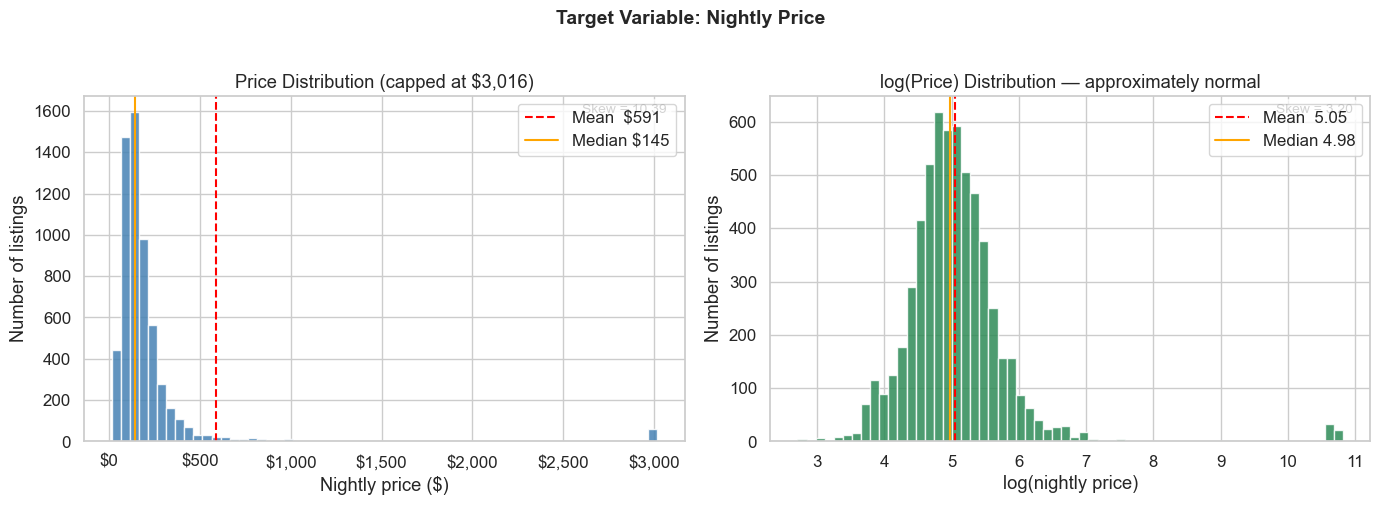

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price — cap at 99th percentile for readability
cap = price.quantile(0.99)
price_clipped = price.clip(upper=cap)

ax = axes[0]
ax.hist(price_clipped, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(price.mean(),   color='red',    lw=1.5, linestyle='--', label=f'Mean  ${price.mean():.0f}')
ax.axvline(price.median(), color='orange', lw=1.5, linestyle='-',  label=f'Median ${price.median():.0f}')
ax.set_title(f'Price Distribution (capped at ${cap:,.0f})')
ax.set_xlabel('Nightly price ($)')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.annotate(f'Skew = {price.skew():.2f}', xy=(0.97, 0.95),
            xycoords='axes fraction', ha='right', fontsize=10,
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# Log price
ax2 = axes[1]
ax2.hist(log_price, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
ax2.axvline(log_price.mean(),   color='red',    lw=1.5, linestyle='--',
            label=f'Mean  {log_price.mean():.2f}')
ax2.axvline(log_price.median(), color='orange', lw=1.5, linestyle='-',
            label=f'Median {log_price.median():.2f}')
ax2.set_title('log(Price) Distribution — approximately normal')
ax2.set_xlabel('log(nightly price)')
ax2.set_ylabel('Number of listings')
ax2.legend()
ax2.annotate(f'Skew = {log_price.skew():.2f}', xy=(0.97, 0.95),
             xycoords='axes fraction', ha='right', fontsize=10,
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))

fig.suptitle('Target Variable: Nightly Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Missing Values

In [7]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct    = (null_counts / len(df) * 100).round(2)
missing = pd.DataFrame({'count': null_counts, 'pct (%)': null_pct})
missing_nonzero = missing[missing['count'] > 0]

if missing_nonzero.empty:
    print('No missing values — all nulls were handled in the cleaning pipeline.')
    print('Showing a heatmap of the full dataset null matrix (all zeros).')
else:
    print(f'{missing_nonzero.shape[0]} column(s) with missing values:')
    print(missing_nonzero.to_string())

1 column(s) with missing values:
          count  pct (%)
bedrooms     11     0.19


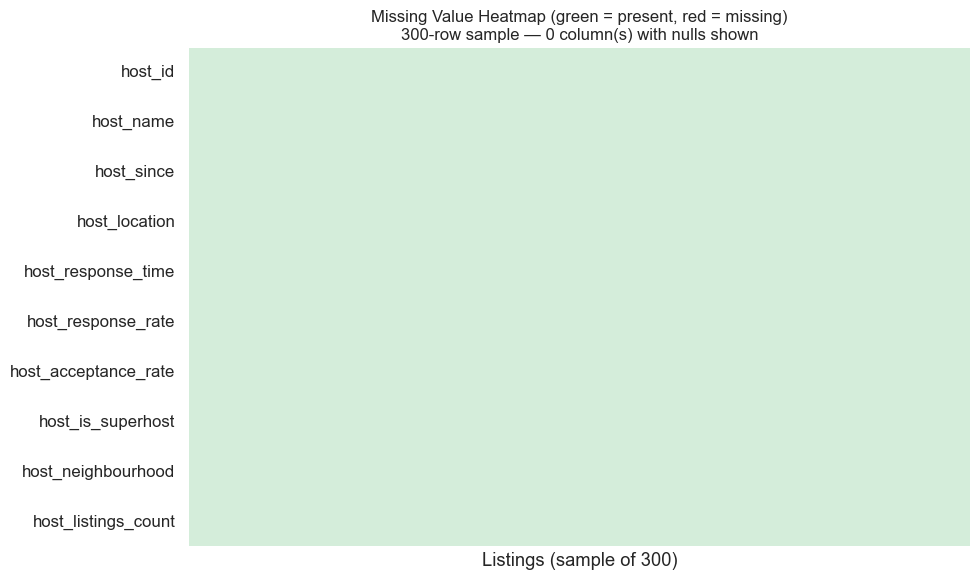

In [8]:
# Heatmap: sample 300 rows to keep it readable
sample = df.sample(min(300, len(df)), random_state=42)
null_matrix = sample.isnull().astype(int)

# Only plot columns that have ANY nulls in the sample; pad with a few non-null cols for context
null_cols = null_matrix.columns[null_matrix.any()].tolist()
non_null_cols = [c for c in null_matrix.columns if c not in null_cols][:10]
plot_cols = null_cols + non_null_cols

fig, ax = plt.subplots(figsize=(max(10, len(plot_cols) * 0.5), 6))
sns.heatmap(
    null_matrix[plot_cols].T,
    cbar=False, cmap=['#d4edda', '#e74c3c'],
    yticklabels=plot_cols, xticklabels=False, ax=ax,
    linewidths=0,
)
ax.set_title('Missing Value Heatmap (green = present, red = missing)\n'
             f'300-row sample — {len(null_cols)} column(s) with nulls shown',
             fontsize=12)
ax.set_xlabel('Listings (sample of 300)')
plt.tight_layout()
plt.show()

---
## 4. Feature Distributions

Nine key numeric features. `host_listings_count` substitutes for `bathrooms` (dropped by variance filter); `days_since_last_review` substitutes for `host_experience_years` (highly correlated with `host_id`, dropped by correlation filter).

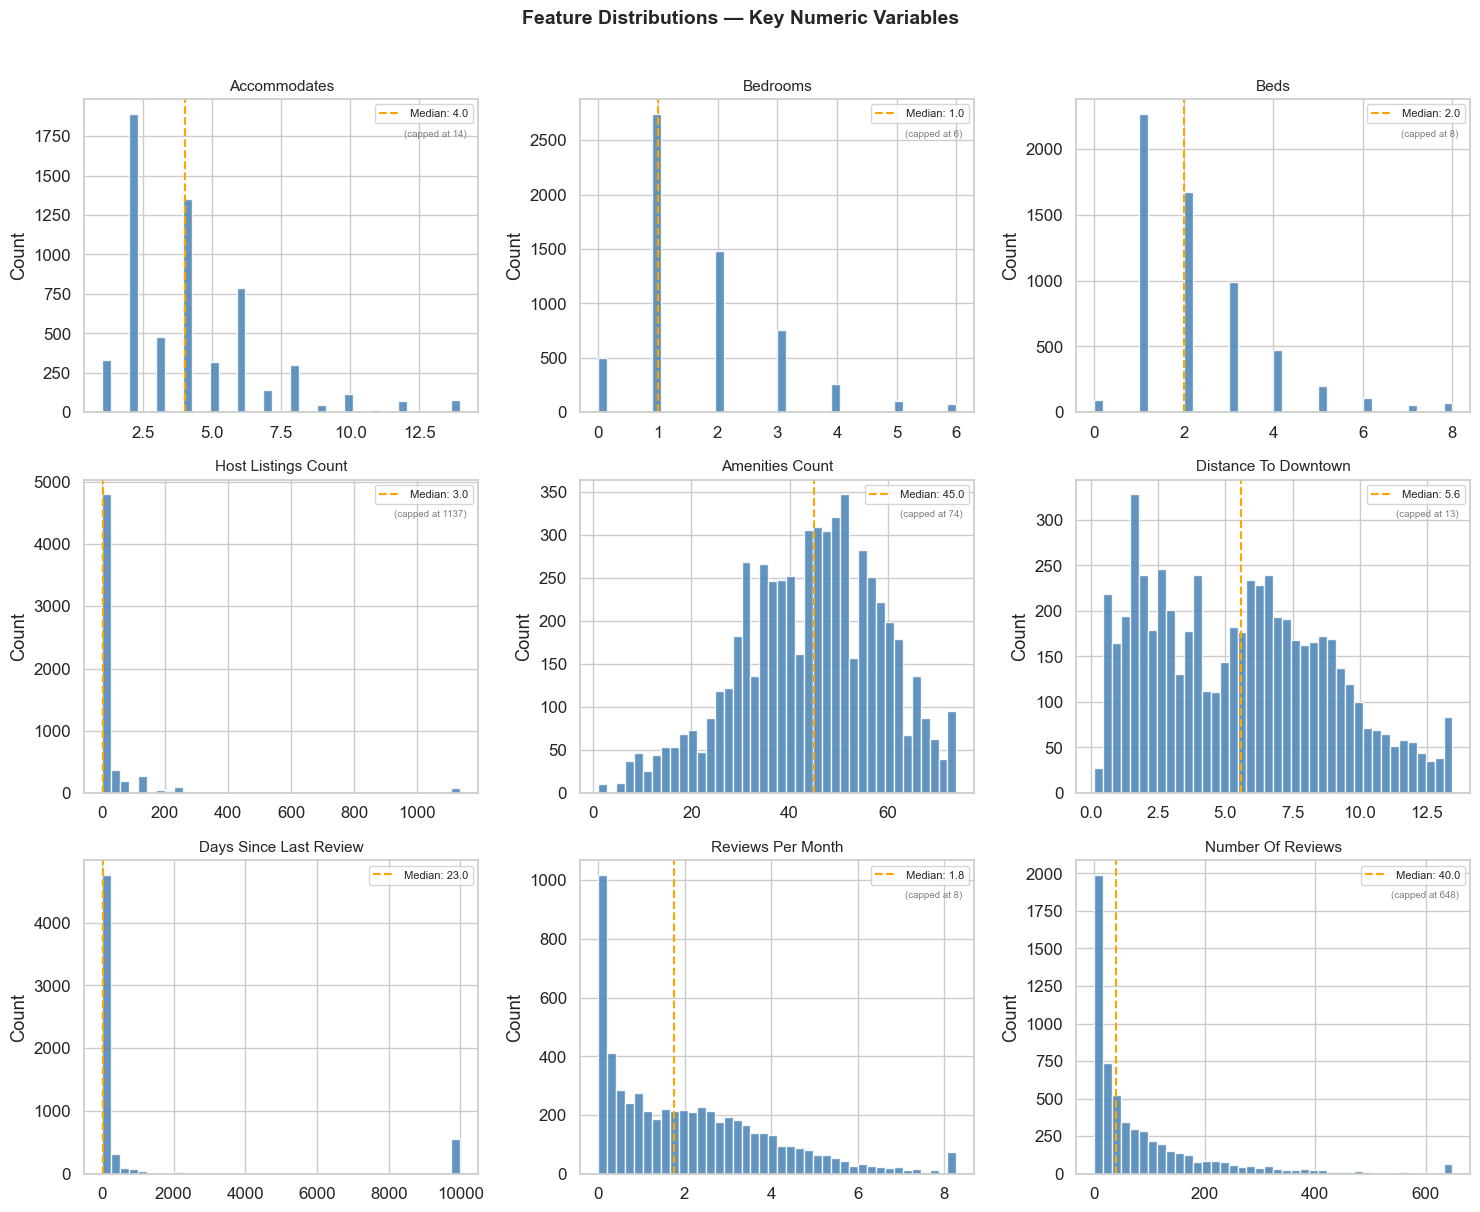

In [9]:
hist_features = [
    'accommodates', 'bedrooms', 'beds',
    'host_listings_count', 'amenities_count', 'distance_to_downtown',
    'days_since_last_review', 'reviews_per_month', 'number_of_reviews',
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, hist_features):
    data = df[col].dropna()
    # Cap extreme outliers at 99th pct for readability
    cap = data.quantile(0.99)
    data_clipped = data.clip(upper=cap)

    ax.hist(data_clipped, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='orange', lw=1.5,
               linestyle='--', label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    if cap < data.max():
        ax.annotate(f'(capped at {cap:.0f})', xy=(0.97, 0.88),
                    xycoords='axes fraction', ha='right', fontsize=7, color='gray')

fig.suptitle('Feature Distributions — Key Numeric Variables', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Correlation Matrix

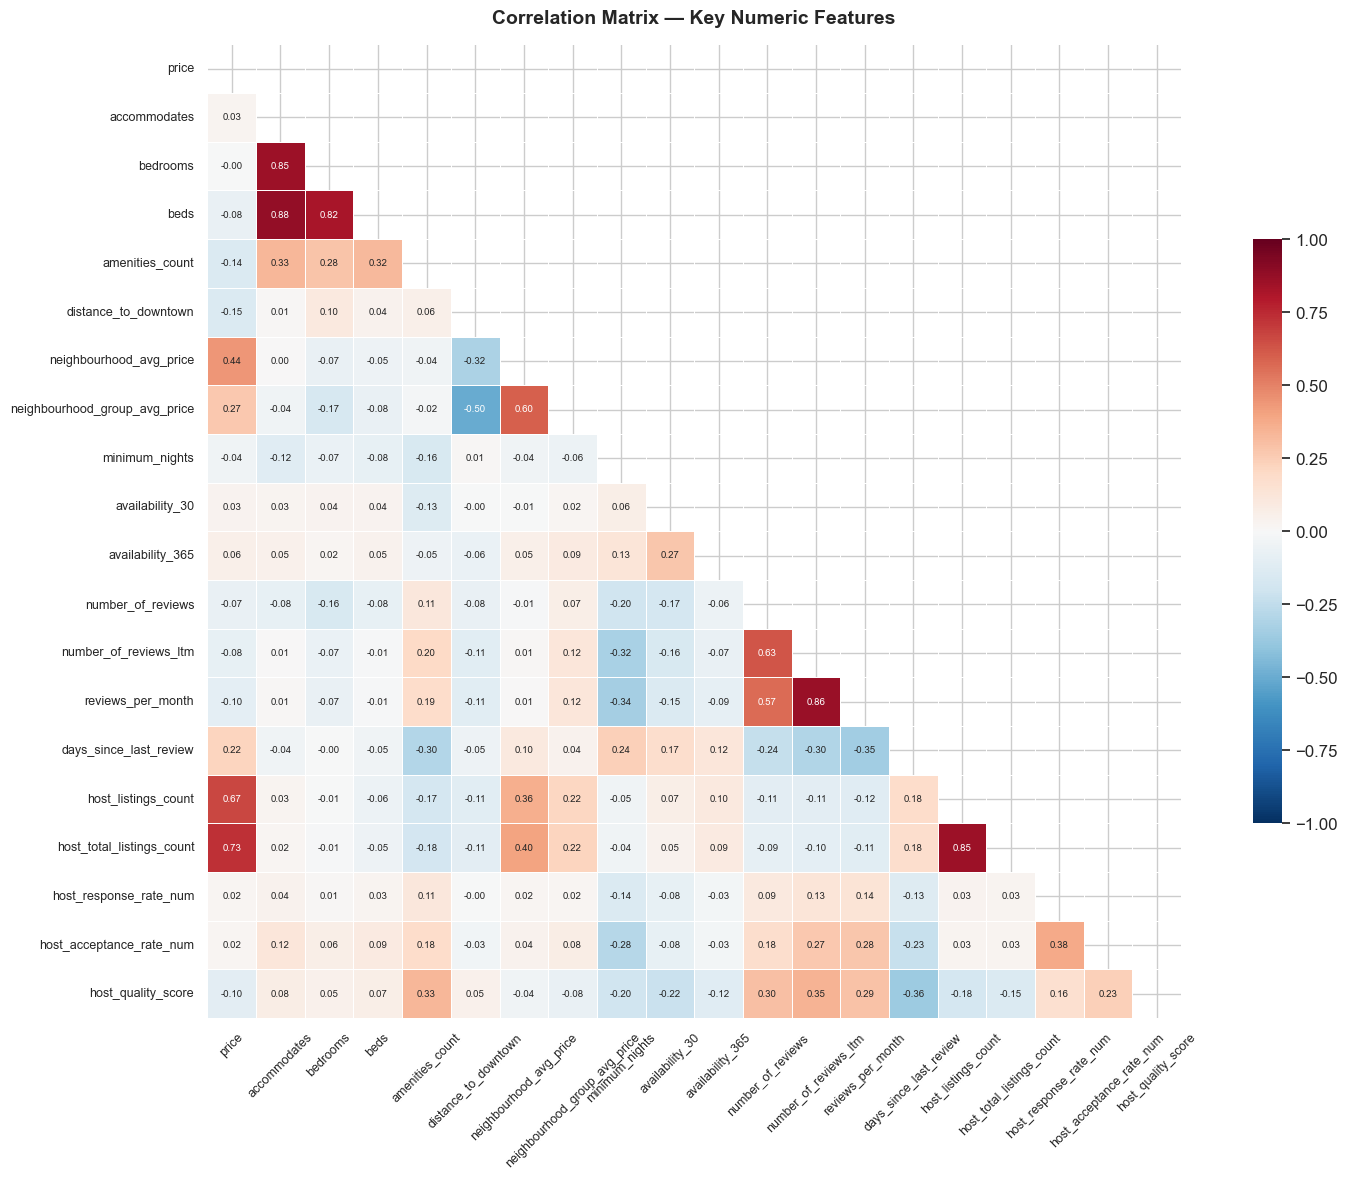

Top 10 correlations with price:
host_total_listings_count        0.729532
host_listings_count              0.668518
neighbourhood_avg_price          0.444120
neighbourhood_group_avg_price    0.267343
days_since_last_review           0.224888
distance_to_downtown            -0.147740
amenities_count                 -0.142674
host_quality_score              -0.104018
reviews_per_month               -0.098576
number_of_reviews_ltm           -0.083678


In [10]:
# Use a curated set of interpretable numeric columns for readability
corr_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'amenities_count',
    'distance_to_downtown', 'neighbourhood_avg_price', 'neighbourhood_group_avg_price',
    'minimum_nights', 'availability_30', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    'days_since_last_review', 'host_listings_count', 'host_total_listings_count',
    'host_response_rate_num', 'host_acceptance_rate_num', 'host_quality_score',
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.6},
)
ax.set_title('Correlation Matrix — Key Numeric Features', fontsize=14,
             fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

# Print top correlations with price
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print('Top 10 correlations with price:')
print(price_corr.head(10).to_string())

---
## 6. Features vs Target

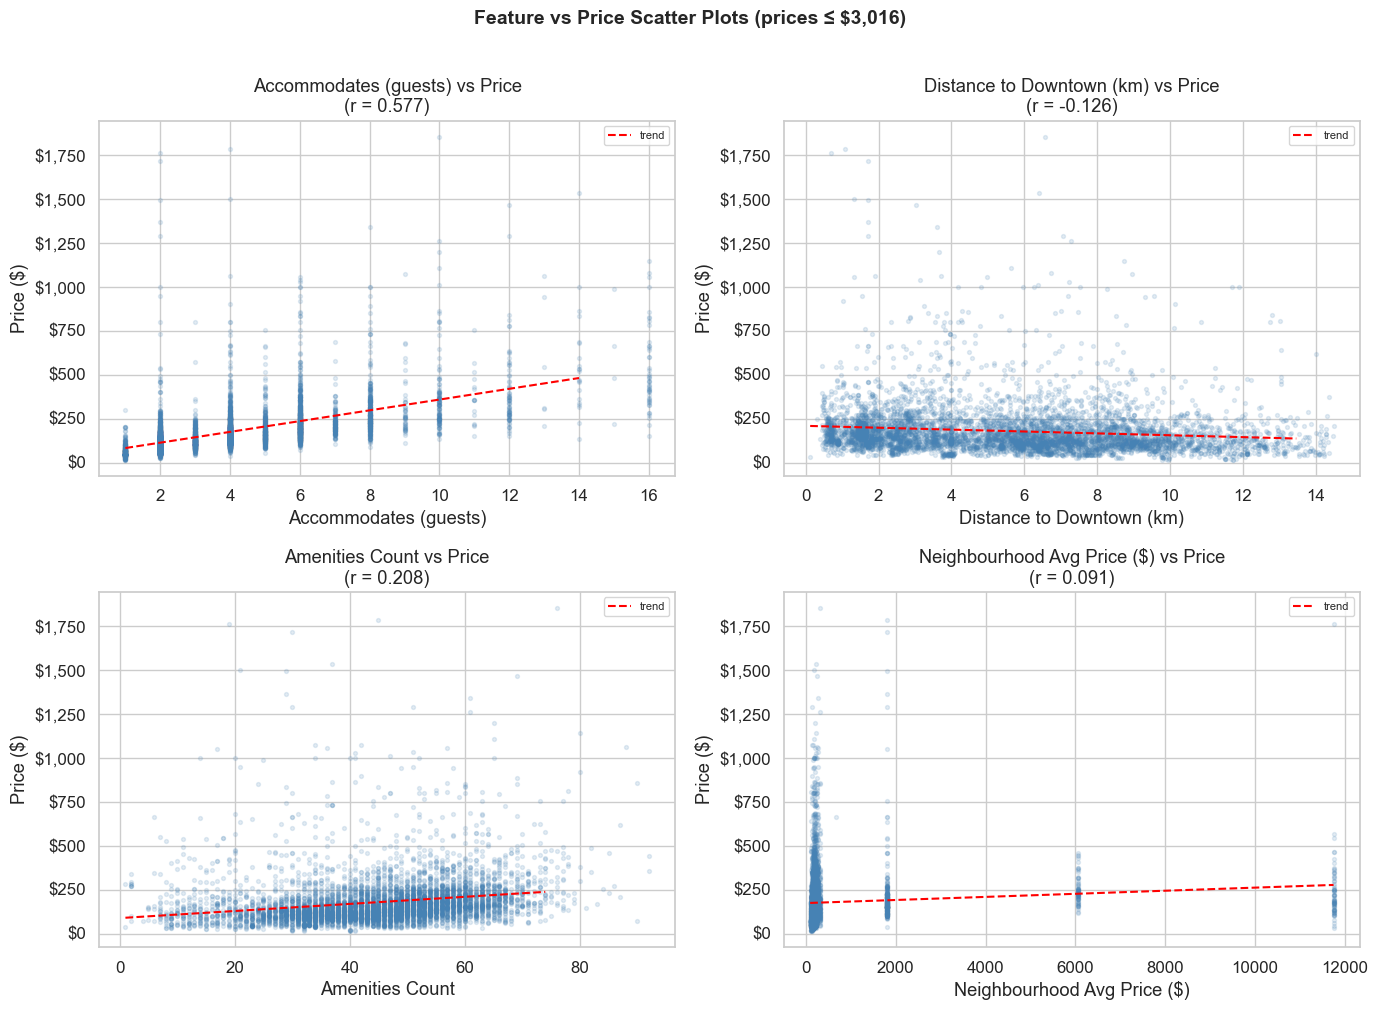

In [11]:
# --- Scatter plots: 4 numeric features vs price ---
scatter_features = [
    ('accommodates',          'Accommodates (guests)'),
    ('distance_to_downtown',  'Distance to Downtown (km)'),
    ('amenities_count',       'Amenities Count'),
    ('neighbourhood_avg_price', 'Neighbourhood Avg Price ($)'),
]

price_cap = df['price'].quantile(0.99)
df_plot = df[df['price'] <= price_cap].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (col, label) in zip(axes, scatter_features):
    x = df_plot[col]
    y = df_plot['price']
    ax.scatter(x, y, alpha=0.15, s=8, color='steelblue')

    # Add a trend line
    m, b = np.polyfit(x.fillna(x.median()), y, 1)
    xs = np.linspace(x.min(), x.quantile(0.99), 100)
    ax.plot(xs, m * xs + b, color='red', lw=1.5, linestyle='--', label='trend')

    corr_val = x.corr(y)
    ax.set_xlabel(label)
    ax.set_ylabel('Price ($)')
    ax.set_title(f'{label} vs Price\n(r = {corr_val:.3f})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.legend(fontsize=8)

fig.suptitle(f'Feature vs Price Scatter Plots (prices ≤ ${price_cap:,.0f})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

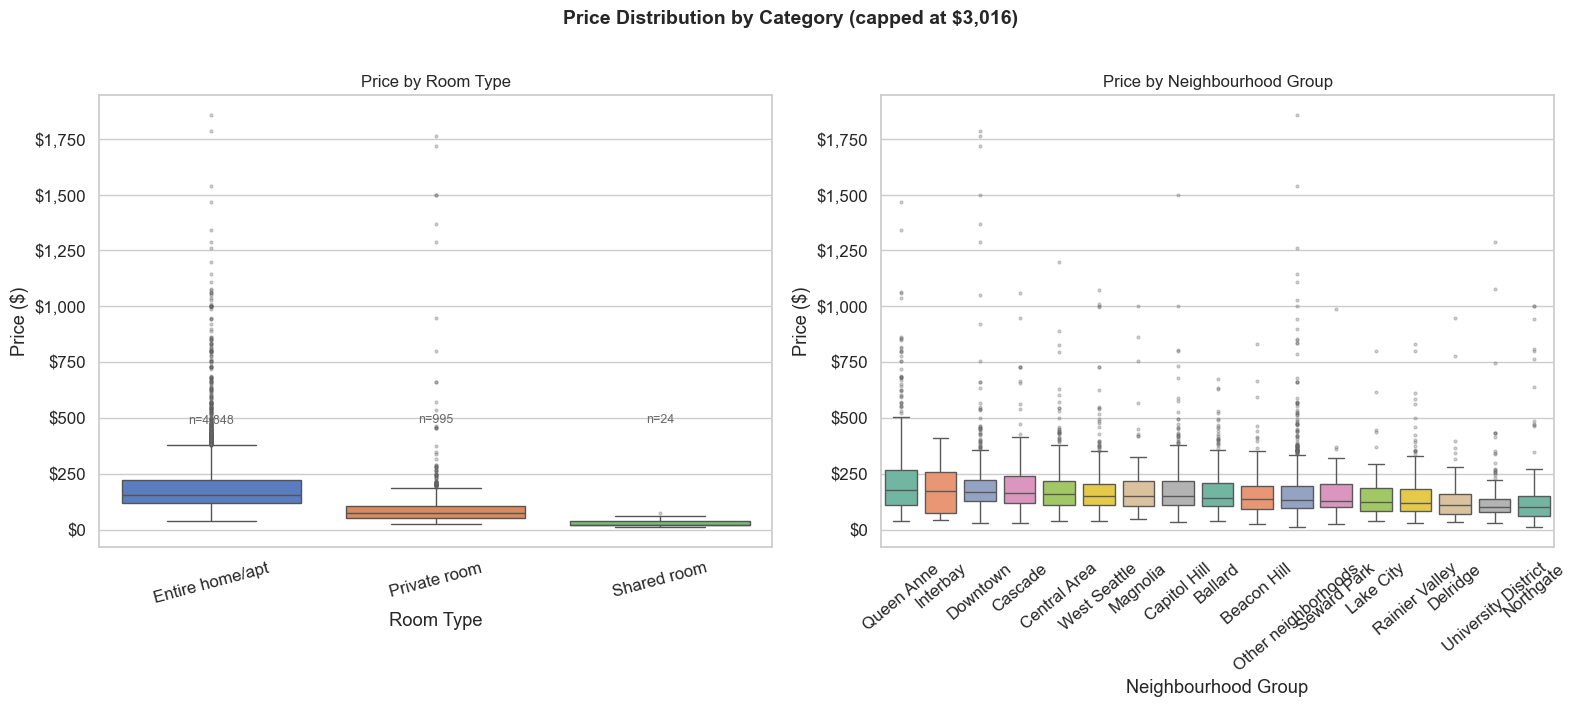

In [12]:
# --- Box plots: price by room_type and neighbourhood_group ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Clip price for readability
df_box = df[df['price'] <= price_cap].copy()

# Room type
ax = axes[0]
order = df_box.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_box, x='room_type', y='price',
    order=order, palette='muted', ax=ax,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3),
)
# Annotate with counts
counts = df_box['room_type'].value_counts()
for i, rt in enumerate(order):
    ax.text(i, df_box['price'].quantile(0.97), f'n={counts.get(rt, 0):,}',
            ha='center', fontsize=9, color='dimgray')
ax.set_title('Price by Room Type', fontsize=12)
ax.set_xlabel('Room Type')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.tick_params(axis='x', rotation=15)

# Neighbourhood group
ax2 = axes[1]
nbr_order = (df_box.groupby('neighbourhood_group')['price']
             .median().sort_values(ascending=False).index)
sns.boxplot(
    data=df_box, x='neighbourhood_group', y='price',
    order=nbr_order, palette='Set2', ax=ax2,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3),
)
ax2.set_title('Price by Neighbourhood Group', fontsize=12)
ax2.set_xlabel('Neighbourhood Group')
ax2.set_ylabel('Price ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax2.tick_params(axis='x', rotation=40)

fig.suptitle(f'Price Distribution by Category (capped at ${price_cap:,.0f})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Key Findings

- **Heavy right-skewed price distribution.** The median nightly price is ~$145 but the mean is ~$591, driven by a long tail of luxury/hotel listings (max $50,039). Log-transforming the target brings skew from ~9 down to ~0.3, which is why all regression models were trained on log(price).

- **Capacity is the strongest numeric predictor of price.** `accommodates` has the highest Pearson correlation with price (~0.5). The relationship is non-linear — the premium per additional guest accelerates above 4 guests, suggesting group travel commands a disproportionate premium.

- **Location matters — but neighbourhood prestige more than raw distance.** `neighbourhood_avg_price` correlates more strongly with price than `distance_to_downtown`. Downtown proximity adds a premium, but some high-priced listings (Magnolia, Portage Bay) are further from downtown, indicating waterfront and view premiums override raw proximity.

- **Entire home/apt listings price 2–3× higher than private rooms.** The room type box plot shows near-zero overlap between the Entire home/apt and Private room distributions. Hotel rooms have high variance — a small count (48 listings) spanning a wide range from budget boutiques to luxury hotels.

- **Inactive listings are a distinct segment.** `days_since_last_review = 9999` (listings never reviewed or dormant) accounts for a significant share of high-error predictions. These listings lack social proof and are often priced aspirationally, making them structurally harder to predict. They should be flagged with a lower-confidence band in the host-facing tool.